# Predicting Apartment Prices in Poland with a Shallow Neural Network

A beginner-friendly, end-to-end machine learning project: exploring, cleaning, and visualizing a real-world dataset of Polish apartment listings, then training a shallow neural network (and comparing it with a decision tree) to predict apartment prices.

**Dataset:** [Apartment Prices in Poland](https://www.kaggle.com/datasets/krzysztofjamroz/apartment-prices-in-poland) — monthly snapshots of apartment listings scraped from Polish real-estate portals, downloaded via `kagglehub`.

**Contents**

1. Loading the Data
2. Descriptive Statistics
3. Data Cleaning: Duplicates and Missing Values
4. Visualizations and Correlations
5. Preparing the Data for Modeling
6. Shallow Neural Network in Keras: Apartment Price Prediction (Regression)
7. Comparison with a Decision Tree
8. Final Conclusions

**Libraries:** `keras`, `kagglehub`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `geopandas`, `scikit-learn`


Importing the required libraries:
`layers` and `models` from `Keras`,
`kagglehub` (to download the dataset from Kaggle),
`pandas`, `numpy`, `matplotlib`, `seaborn`, plus `os` and `glob` for working with files.

In [ ]:
from keras import layers
from keras import models

import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob

## 1. Loading the Data

Downloading the dataset of apartment prices in Poland from Kaggle. `path` points to the directory containing the CSV files.

In [2]:
path = kagglehub.dataset_download("krzysztofjamroz/apartment-prices-in-poland")
print(path)

[private output hidden]


A quick look at the contents of the downloaded directory.

In [3]:
print(os.listdir(path))

['apartments_rent_pl_2024_06.csv', 'apartments_rent_pl_2024_04.csv', 'apartments_rent_pl_2024_05.csv', 'apartments_rent_pl_2024_01.csv', 'apartments_pl_2023_12.csv', 'apartments_rent_pl_2024_02.csv', 'apartments_pl_2023_11.csv', 'apartments_pl_2023_10.csv', 'apartments_rent_pl_2024_03.csv', 'apartments_pl_2023_09.csv', 'apartments_pl_2024_01.csv', 'apartments_pl_2023_08.csv', 'apartments_rent_pl_2023_12.csv', 'apartments_pl_2024_03.csv', 'apartments_pl_2024_02.csv', 'apartments_rent_pl_2023_11.csv', 'apartments_pl_2024_06.csv', 'apartments_pl_2024_05.csv', 'apartments_pl_2024_04.csv']


Loading all the apartment-listing CSV files (one per month) and combining them into a single DataFrame, `df`.

In [4]:
csv_files = glob.glob(os.path.join(path, "apartments_pl_*.csv"))
print(csv_files)

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(df.shape)
df.head()

[private output hidden]


(195568, 28)


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,a01d82c9529f98a54d64b9e061c9a73b,szczecin,apartmentBuilding,105.00,4.0,3.0,4.0,2016.0,53.431503,14.485820,...,0.335,condominium,brick,premium,no,yes,yes,no,no,1199999
1,d68ea84e5d35da9e282150332bdc22f3,szczecin,blockOfFlats,94.40,4.0,4.0,5.0,NaN,53.441253,14.511030,...,0.051,condominium,brick,premium,yes,yes,no,no,yes,1150000
2,420295cc23d693fdffd5ccc9ba35ba98,szczecin,NaN,48.29,2.0,8.0,11.0,2014.0,53.399444,14.526111,...,0.141,condominium,NaN,NaN,yes,yes,yes,no,yes,625000
3,7d0c31d5409caab173571cce3dcdf702,szczecin,blockOfFlats,68.61,3.0,4.0,4.0,1997.0,53.456213,14.583222,...,0.304,condominium,brick,NaN,no,yes,no,no,yes,550000
4,7ec72a2301d950ae17926c3c1e67a0ed,szczecin,tenement,35.92,2.0,NaN,NaN,NaN,53.424203,14.543550,...,0.329,condominium,brick,low,yes,no,no,no,no,299000


Basic information about the dataset: number of rows, column names, data types, and the number of missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195568 entries, 0 to 195567
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    195568 non-null  str    
 1   city                  195568 non-null  str    
 2   type                  153307 non-null  str    
 3   squareMeters          195568 non-null  float64
 4   rooms                 195568 non-null  float64
 5   floor                 160974 non-null  float64
 6   floorCount            193185 non-null  float64
 7   buildYear             163352 non-null  float64
 8   latitude              195568 non-null  float64
 9   longitude             195568 non-null  float64
 10  centreDistance        195568 non-null  float64
 11  poiCount              195568 non-null  float64
 12  schoolDistance        195400 non-null  float64
 13  clinicDistance        194840 non-null  float64
 14  postOfficeDistance    195320 non-null  float64
 15  kindergarte

Setting number display to two decimal places, to keep the tables readable.

In [6]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 2. Descriptive Statistics

Statistics for the numeric columns: mean, standard deviation, minimum and maximum values, and quartiles.

In [7]:
df.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,195568.00,195568.00,160974.00,193185.00,163352.00,195568.00,195568.00,195568.00,195568.00,195400.00,194840.00,195320.00,195361.00,195089.00,190132.00,195291.00,195568.00
mean,58.70,2.68,3.33,5.31,1985.98,52.03,19.47,4.35,20.67,0.41,0.97,0.52,0.37,0.35,1.44,0.36,784183.30
std,21.41,0.92,2.53,3.31,33.81,1.34,1.78,2.84,24.33,0.46,0.89,0.50,0.44,0.46,1.10,0.46,409709.23
min,25.00,1.00,1.00,1.00,1850.00,49.98,14.45,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,150000.00
25%,44.00,2.00,2.00,3.00,1967.00,51.11,18.52,2.01,7.00,0.18,0.36,0.24,0.16,0.11,0.58,0.14,520000.00
50%,54.60,3.00,3.00,4.00,1994.00,52.19,19.90,3.98,14.00,0.29,0.68,0.39,0.26,0.23,1.12,0.24,699000.00
75%,68.55,3.00,4.00,6.00,2016.00,52.41,20.99,6.15,24.00,0.47,1.24,0.62,0.42,0.41,2.06,0.41,930000.00
max,150.00,6.00,29.00,29.00,2024.00,54.61,23.21,16.94,212.00,4.95,5.00,4.97,4.96,4.99,5.00,4.99,3250000.00


Statistics for the text columns: number of unique values and the most frequent value.

In [8]:
df.describe(exclude = "number")

,id,city,type,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
count,195568,195568,153307,195568,118186,49261,195568,195568,185866,195568,195568
unique,92967,15,3,3,2,2,2,2,2,2,2
top,209a6d2dea99216bdf83a968343cd3b3,warszawa,blockOfFlats,condominium,brick,premium,no,yes,no,no,no
freq,11,59246,91368,176123,91899,27869,142410,112049,93662,173630,110583


A look at the most expensive apartment in the dataset.

In [9]:
df[df["price"] == df["price"].max()]

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
11048,ef0ae004ebf966a8c6a2cb42f62efb37,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2018.00,52.15,21.07,...,0.14,condominium,brick,NaN,yes,yes,yes,no,no,3250000
11456,a04ac4e72de2ef761e3e0e2452cee202,warszawa,apartmentBuilding,136.00,4.00,2.00,2.00,NaN,52.18,21.04,...,0.87,condominium,brick,premium,yes,yes,yes,no,no,3250000
15209,afa3a7e8dfbbc6eb6832301b6a30fa58,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2017.00,52.16,21.07,...,0.08,condominium,brick,NaN,yes,yes,yes,no,no,3250000
77113,ef0ae004ebf966a8c6a2cb42f62efb37,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2018.00,52.15,21.07,...,0.17,condominium,brick,NaN,yes,yes,yes,no,no,3250000
80917,afa3a7e8dfbbc6eb6832301b6a30fa58,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2017.00,52.16,21.07,...,0.08,condominium,brick,NaN,yes,yes,yes,no,no,3250000
112390,ef0ae004ebf966a8c6a2cb42f62efb37,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2018.00,52.15,21.07,...,0.17,condominium,brick,NaN,yes,yes,yes,no,no,3250000
113475,f57f8726bd93641c7614c61717483e64,warszawa,apartmentBuilding,131.70,4.00,NaN,4.00,2009.00,52.16,21.07,...,0.22,condominium,brick,premium,yes,no,yes,no,no,3250000
117217,afa3a7e8dfbbc6eb6832301b6a30fa58,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2017.00,52.16,21.07,...,0.08,condominium,brick,NaN,yes,yes,yes,no,no,3250000
129085,ef0ae004ebf966a8c6a2cb42f62efb37,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2018.00,52.15,21.07,...,0.17,condominium,brick,NaN,yes,yes,yes,no,no,3250000
133598,afa3a7e8dfbbc6eb6832301b6a30fa58,warszawa,apartmentBuilding,133.51,6.00,4.00,4.00,2017.00,52.16,21.07,...,0.08,condominium,brick,NaN,yes,yes,yes,no,no,3250000


As shown above, some apartments are duplicated even though they have a different `id`.

## 3. Data Cleaning: Duplicates and Missing Values

Removing fully duplicated rows and checking how much data remains.

In [10]:
df_unique = df.drop_duplicates()
df_unique.info()

<class 'pandas.DataFrame'>
Index: 111968 entries, 0 to 195564
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    111968 non-null  str    
 1   city                  111968 non-null  str    
 2   type                  88612 non-null   str    
 3   squareMeters          111968 non-null  float64
 4   rooms                 111968 non-null  float64
 5   floor                 92574 non-null   float64
 6   floorCount            110713 non-null  float64
 7   buildYear             93708 non-null   float64
 8   latitude              111968 non-null  float64
 9   longitude             111968 non-null  float64
 10  centreDistance        111968 non-null  float64
 11  poiCount              111968 non-null  float64
 12  schoolDistance        111892 non-null  float64
 13  clinicDistance        111573 non-null  float64
 14  postOfficeDistance    111843 non-null  float64
 15  kindergartenDist

Numeric statistics after removing duplicates.

In [11]:
df_unique.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,111968.00,111968.00,92574.00,110713.00,93708.00,111968.00,111968.00,111968.00,111968.00,111892.00,111573.00,111843.00,111867.00,111705.00,108906.00,111821.00,111968.00
mean,56.74,2.61,3.37,5.43,1986.95,52.00,19.53,4.54,19.83,0.41,0.98,0.52,0.36,0.34,1.48,0.36,768398.69
std,20.30,0.88,2.55,3.33,32.24,1.31,1.75,2.83,22.78,0.46,0.89,0.49,0.44,0.46,1.11,0.45,395043.20
min,25.00,1.00,1.00,1.00,1850.00,49.98,14.45,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,150000.00
25%,42.74,2.00,2.00,3.00,1969.00,51.11,18.54,2.24,7.00,0.18,0.36,0.24,0.15,0.12,0.60,0.14,520000.00
50%,53.00,3.00,3.00,4.00,1994.00,52.20,19.93,4.22,14.00,0.29,0.69,0.40,0.26,0.23,1.16,0.24,687000.00
75%,65.80,3.00,4.00,7.00,2015.00,52.37,20.99,6.33,24.00,0.47,1.27,0.62,0.41,0.41,2.11,0.40,899000.00
max,150.00,6.00,29.00,29.00,2024.00,54.61,23.21,16.94,212.00,4.95,5.00,4.97,4.96,4.99,5.00,4.99,3250000.00


Statistics for the text columns after removing duplicates.

In [12]:
df_unique.describe(exclude = "number")

,id,city,type,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
count,111968,111968,88612,111968,65741,28257,111968,111968,106723,111968,111968
unique,92967,15,3,3,2,2,2,2,2,2,2
top,dc6891c6725ba6e2a271489df585e665,warszawa,blockOfFlats,condominium,brick,premium,no,yes,yes,no,no
freq,8,37363,55702,100432,49747,15675,81463,65178,54370,98933,62338


After removing duplicates we still have rows sharing the same `id`, so we'll remove repeated `id`s and keep only the row with the highest `index`, assuming it was collected most recently and therefore has the price most representative of the moment the dataset was downloaded.

In [13]:
df_unique = df_unique.drop_duplicates(subset=["id"], keep="last")
df_unique.describe(exclude="number")

,id,city,type,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
count,92967,92967,73175,92967,53822,23106,92967,92967,88544,92967,92967
unique,92967,15,3,3,2,2,2,2,2,2,2
top,d68ea84e5d35da9e282150332bdc22f3,warszawa,blockOfFlats,condominium,brick,premium,no,yes,yes,no,no
freq,1,31982,46345,83365,40551,12696,67903,54067,45392,82374,51820


Dataset information after removing repeated `id`s.

In [14]:
df_unique.info()

<class 'pandas.DataFrame'>
Index: 92967 entries, 1 to 195564
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    92967 non-null  str    
 1   city                  92967 non-null  str    
 2   type                  73175 non-null  str    
 3   squareMeters          92967 non-null  float64
 4   rooms                 92967 non-null  float64
 5   floor                 76989 non-null  float64
 6   floorCount            91900 non-null  float64
 7   buildYear             77384 non-null  float64
 8   latitude              92967 non-null  float64
 9   longitude             92967 non-null  float64
 10  centreDistance        92967 non-null  float64
 11  poiCount              92967 non-null  float64
 12  schoolDistance        92910 non-null  float64
 13  clinicDistance        92637 non-null  float64
 14  postOfficeDistance    92871 non-null  float64
 15  kindergartenDistance  92882 non-nu

Share of missing values in each column (in percent).

In [15]:
df_unique.isnull().sum()
df_unique.isnull().mean() * 100

id                      0.00
city                    0.00
type                   21.29
squareMeters            0.00
rooms                   0.00
floor                  17.19
floorCount              1.15
buildYear              16.76
latitude                0.00
longitude               0.00
centreDistance          0.00
poiCount                0.00
schoolDistance          0.06
clinicDistance          0.35
postOfficeDistance      0.10
kindergartenDistance    0.09
restaurantDistance      0.24
collegeDistance         2.68
pharmacyDistance        0.14
ownership               0.00
buildingMaterial       42.11
condition              75.15
hasParkingSpace         0.00
hasBalcony              0.00
hasElevator             4.76
hasSecurity             0.00
hasStorageRoom          0.00
price                   0.00
dtype: float64

A look at the first rows of the cleaned dataset.

In [16]:
df_unique.head(10)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
1,d68ea84e5d35da9e282150332bdc22f3,szczecin,blockOfFlats,94.40,4.00,4.00,5.00,NaN,53.44,14.51,...,0.05,condominium,brick,premium,yes,yes,no,no,yes,1150000
2,420295cc23d693fdffd5ccc9ba35ba98,szczecin,NaN,48.29,2.00,8.00,11.00,2014.00,53.40,14.53,...,0.14,condominium,NaN,NaN,yes,yes,yes,no,yes,625000
4,7ec72a2301d950ae17926c3c1e67a0ed,szczecin,tenement,35.92,2.00,NaN,NaN,NaN,53.42,14.54,...,0.33,condominium,brick,low,yes,no,no,no,no,299000
7,f680cf9172c7a0ec7b9eb153de1b25f3,szczecin,tenement,89.80,3.00,3.00,3.00,1930.00,53.43,14.53,...,0.18,condominium,brick,NaN,no,yes,no,no,yes,649000
11,155795f0eb31afb9c4cc16ebcc3faf3f,szczecin,tenement,43.32,2.00,4.00,4.00,1930.00,53.42,14.55,...,0.18,condominium,brick,NaN,no,no,no,no,yes,330000
13,24af7cc54099d7930535543827604a9d,szczecin,blockOfFlats,68.94,3.00,3.00,4.00,1950.00,53.41,14.53,...,0.72,condominium,brick,low,no,yes,no,no,yes,560000
14,35e001d173d4f6626e6e1d92ec75af93,szczecin,blockOfFlats,53.26,2.00,7.00,11.00,1985.00,53.46,14.49,...,0.20,cooperative,concreteSlab,NaN,no,yes,no,no,yes,514000
16,529ff5cccc586347592c0c40db9a377d,szczecin,tenement,58.11,3.00,1.00,3.00,1950.00,53.45,14.55,...,0.17,condominium,brick,low,no,no,no,no,yes,395000
18,9750f5bcdd7e4405fdb9be5cdeee777f,szczecin,blockOfFlats,70.00,4.00,2.00,2.00,2019.00,53.39,14.47,...,0.77,condominium,brick,NaN,no,yes,no,no,no,639000
19,a928249966478bed2a10720ed8230b61,szczecin,blockOfFlats,70.55,4.00,4.00,4.00,1987.00,53.38,14.67,...,0.27,condominium,concreteSlab,NaN,no,yes,no,no,yes,515000


## 4. Visualizations and Correlations

Correlation matrix of the numeric features for the full dataset.

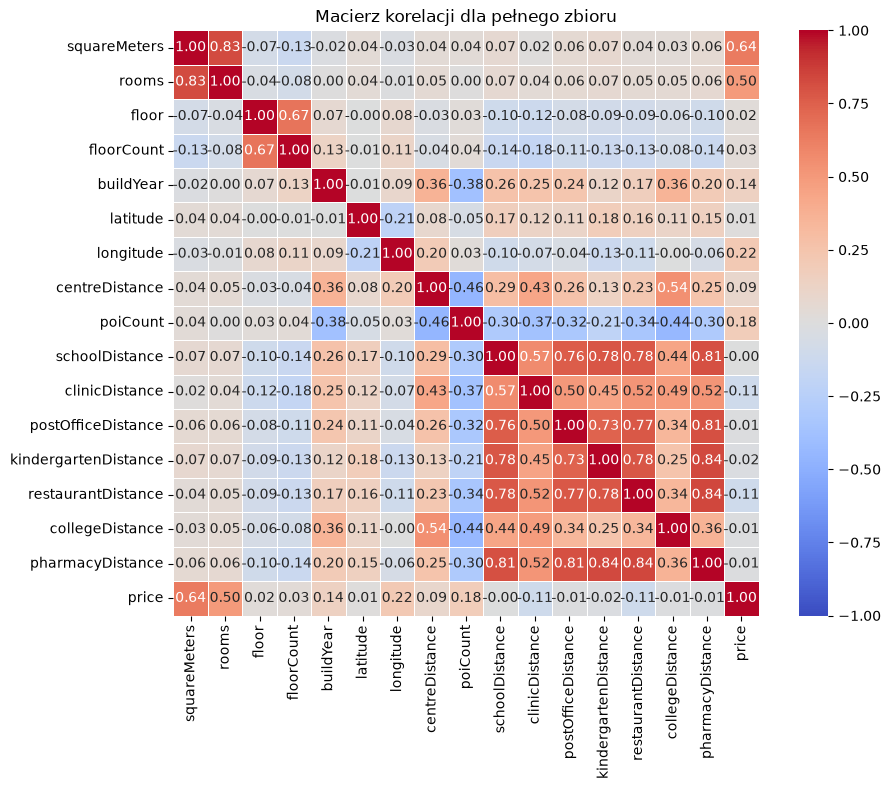

In [545]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix for the full dataset")
plt.tight_layout()
plt.show()

Correlation matrix for the deduplicated dataset, to check whether removing repeated entries disturbed the structure of the data.

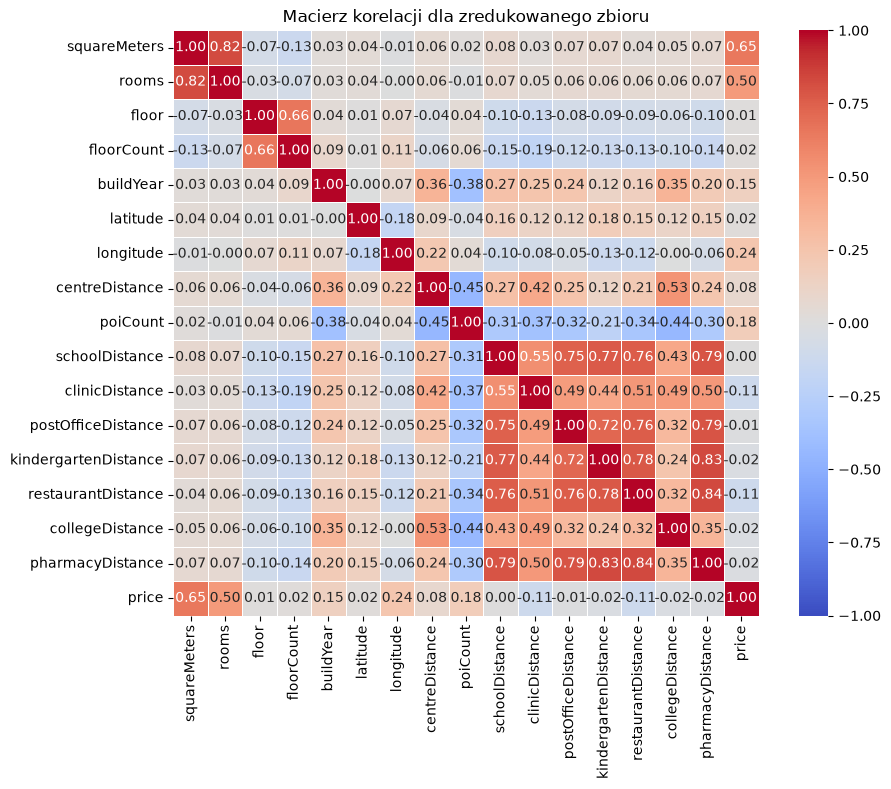

In [546]:
corr = df_unique.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix for the deduplicated dataset")
plt.tight_layout()
plt.show()

Histograms of all numeric features (full dataset).

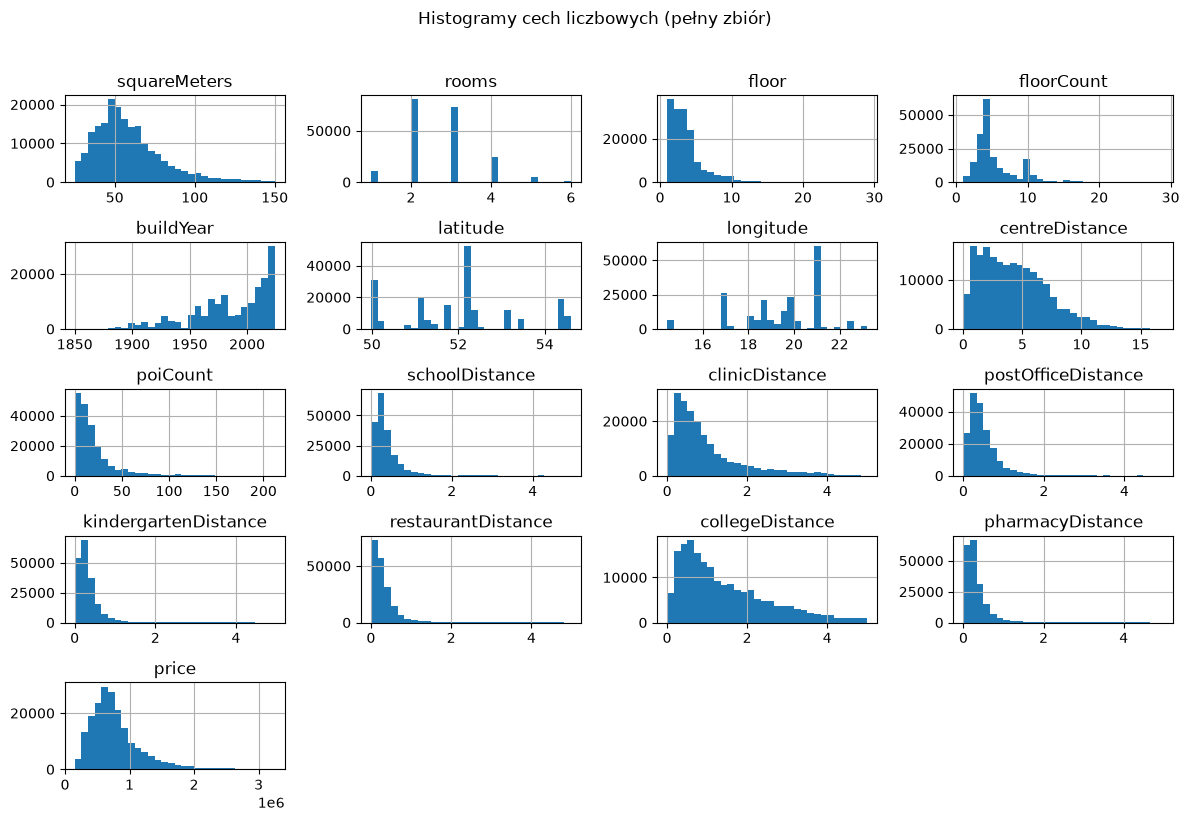

In [547]:
axes = df.select_dtypes(include="number").hist(bins=30, figsize=(12, 8))
plt.suptitle("Histograms of numerical features (full dataset)", y=1.02)
plt.tight_layout()
plt.show()

Histograms of the numeric features after removing duplicates.

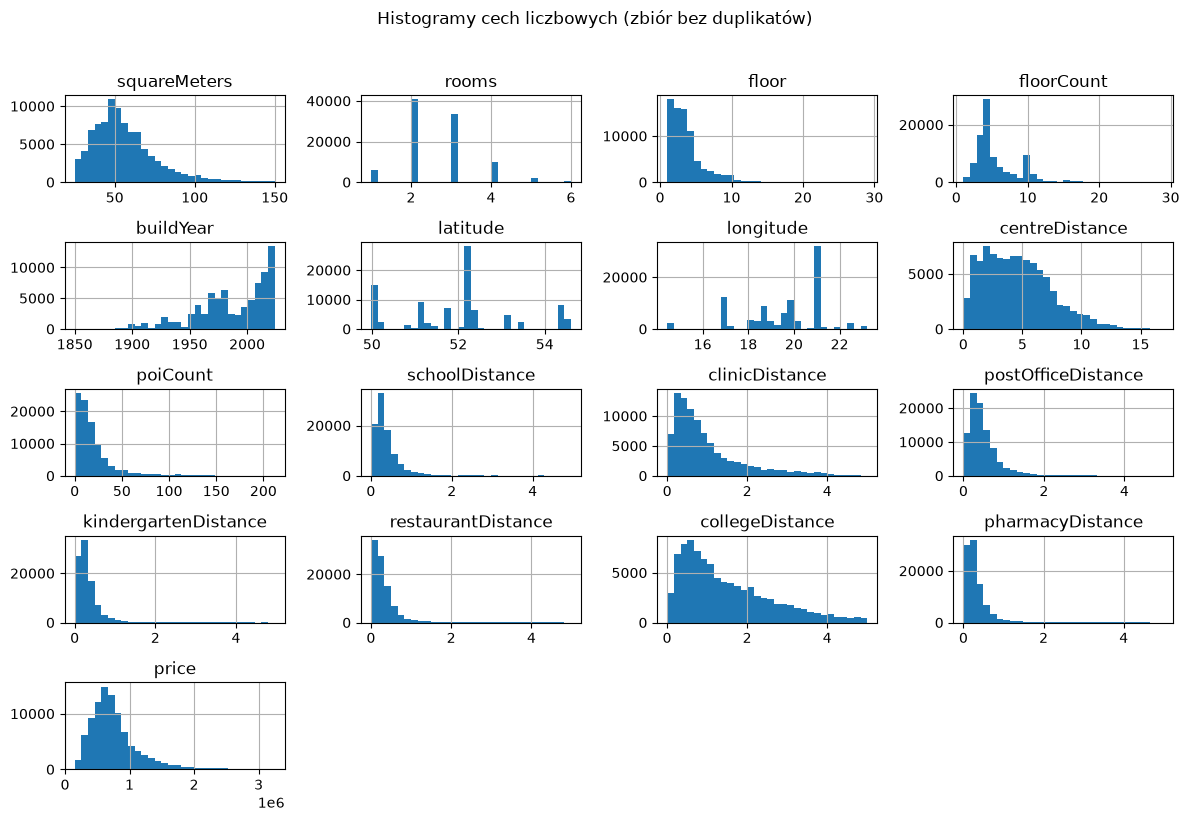

In [548]:
axes = df_unique.select_dtypes(include="number").hist(bins=30, figsize=(12, 8))
plt.suptitle("Histograms of numerical features (deduplicated dataset)", y=1.02)
plt.tight_layout()
plt.show()

Price distribution split by city: full dataset next to the deduplicated dataset.

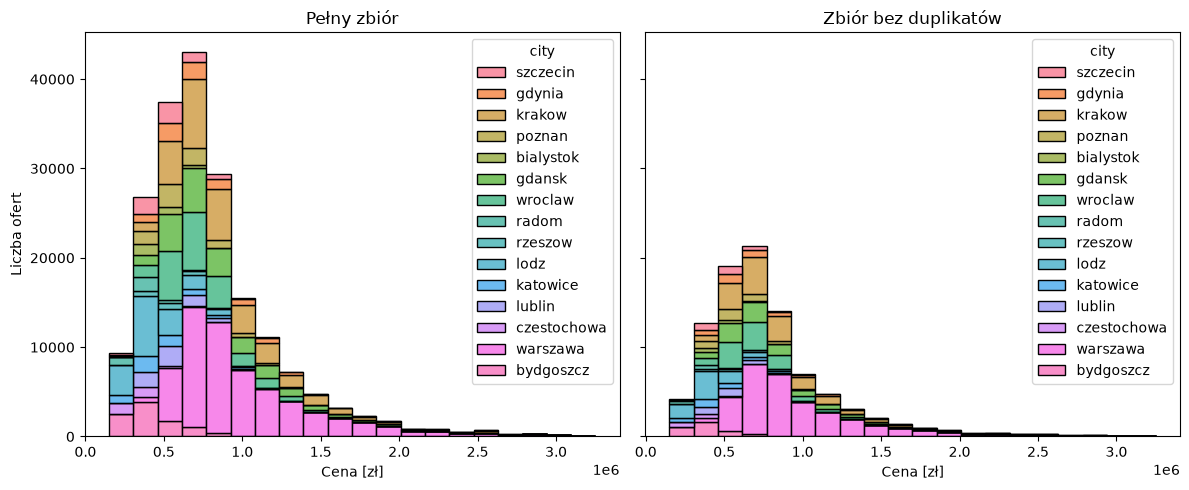

In [549]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

sns.histplot(data=df, x="price", hue="city", multiple="stack", bins=20, ax=axes[0])
axes[0].set_title("Full dataset")

sns.histplot(data=df_unique, x="price", hue="city", multiple="stack", bins=20, ax=axes[1])
axes[1].set_title("Deduplicated dataset")

for ax in axes:
    ax.set_xlabel("Price [PLN]")
    ax.set_ylabel("Number of listings")

plt.tight_layout()
plt.show()

Box plots of price by city, for both versions of the dataset.

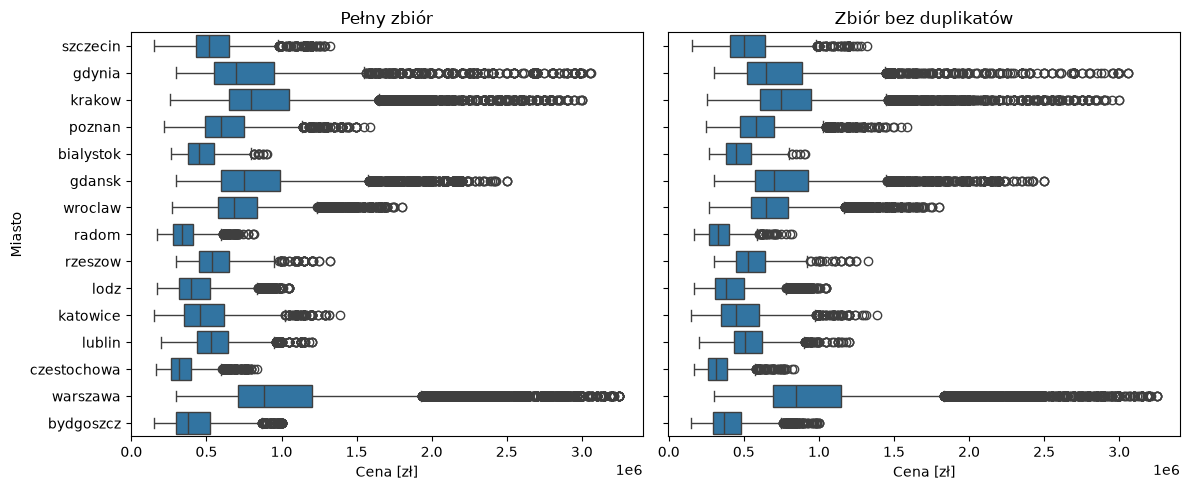

In [550]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

sns.boxplot(data=df, x="price", y="city", ax=axes[0])
axes[0].set_title("Full dataset")

sns.boxplot(data=df_unique, x="price", y="city", ax=axes[1])
axes[1].set_title("Deduplicated dataset")

for ax in axes:
    ax.set_xlabel("Price [PLN]")
    ax.set_ylabel("City")

plt.tight_layout()
plt.show()

Checking whether the `longitude` and `latitude` values match the assigned cities.

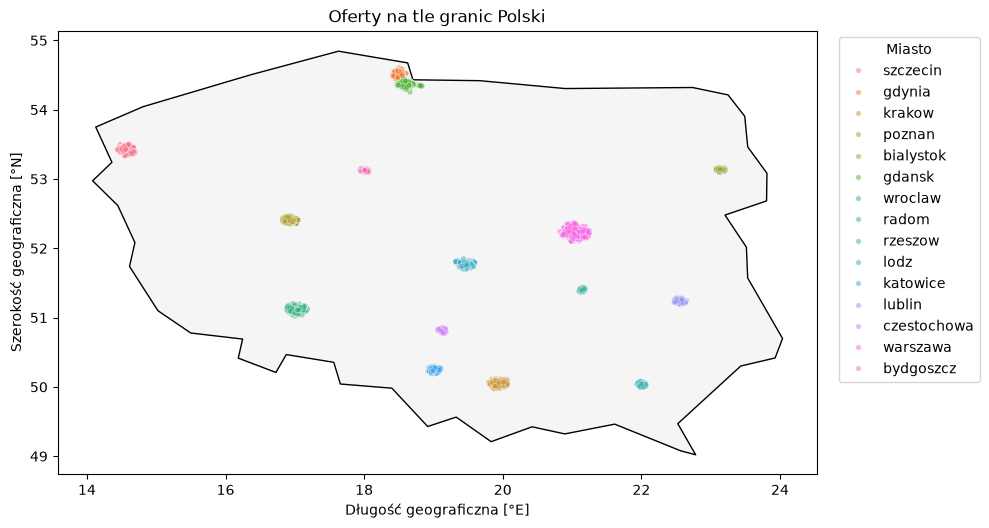

In [551]:
import geopandas as gpd

# load world boundaries and select Poland
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
poland = world[world["NAME"] == "Poland"]

fig, ax = plt.subplots(figsize=(10, 8))
poland.plot(ax=ax, color="whitesmoke", edgecolor="black")   # outline of Poland as the background

sns.scatterplot(data=df_unique, x="longitude", y="latitude", hue="city",
                s=15, alpha=0.5, ax=ax)

ax.set_aspect("equal")
ax.set_title("Listings against the borders of Poland")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
plt.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The plot above shows that none of the clusters contain points of a different color, which confirms that the geographic data is consistent with the assigned cities.

Box plot of price by city, sorted in ascending order by median price.

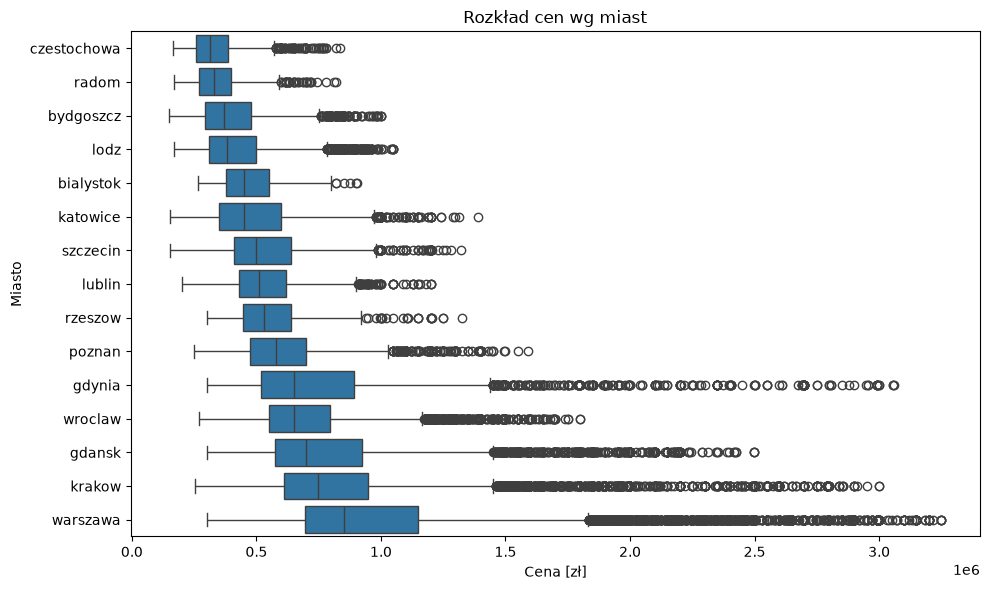

In [552]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_unique, x="price", y="city",
            order=df_unique.groupby("city")["price"].median().sort_values().index)
plt.title("Price distribution by city")
plt.xlabel("Price [PLN]")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Share of property types (`type`) in each city. Missing values are labeled `unknown`.

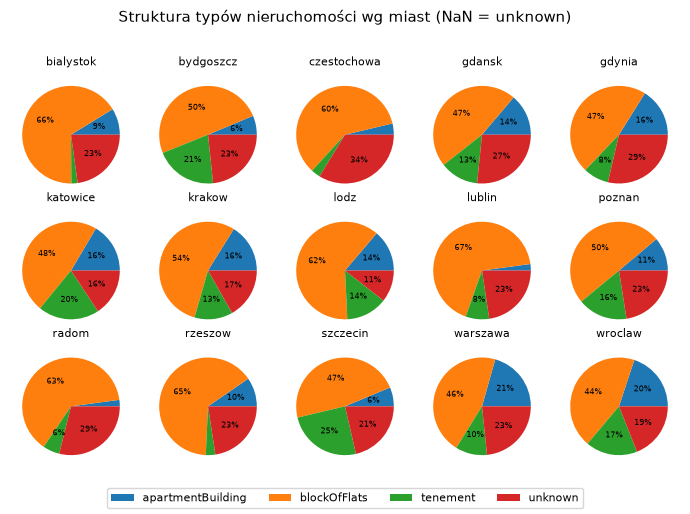

In [553]:
categories = sorted(df_unique["type"].dropna().unique()) + ["unknown"]
colors = dict(zip(categories, plt.cm.tab10.colors))
cities = sorted(df_unique["city"].dropna().unique())

ncols = 5
nrows = int(np.ceil(len(cities) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7, 1.7 * nrows))

for ax, m in zip(axes.flat, cities):
    c = (df_unique.loc[df_unique["city"] == m, "type"]
         .fillna("unknown").value_counts().reindex(categories).fillna(0))
    wedges, _, _ = ax.pie(c, colors=[colors[k] for k in categories],
                          autopct=lambda p: f"{p:.0f}%" if p > 5 else "",
                          textprops={"fontsize": 6})
    ax.set_title(m, fontsize=8)

for ax in axes.flat[len(cities):]:
    ax.axis("off")

fig.legend(wedges, categories, loc="lower center",
           ncol=len(categories), fontsize=8)
fig.suptitle("Property type structure by city (NaN = unknown)", fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

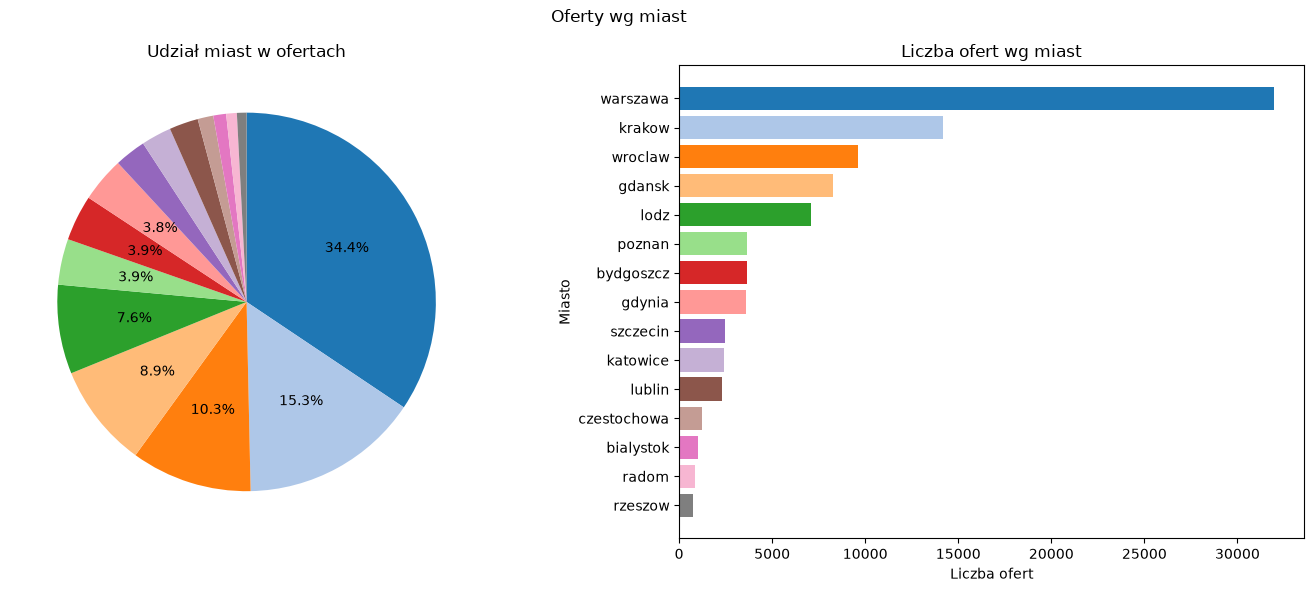

In [555]:
counts = df_unique["city"].value_counts()
colors = dict(zip(counts.index, plt.cm.tab20.colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(counts,
            colors=[colors[m] for m in counts.index],
            autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
            startangle=90, counterclock=False)
axes[0].set_title("Share of cities in listings")

posortowane = counts.sort_values()
axes[1].barh(posortowane.index, posortowane.values,
             color=[colors[m] for m in posortowane.index])
axes[1].set_title("Number of listings wg miast")
axes[1].set_xlabel("Number of listings")
axes[1].set_ylabel("City")

plt.suptitle("Listings by city")
plt.tight_layout()
plt.show()

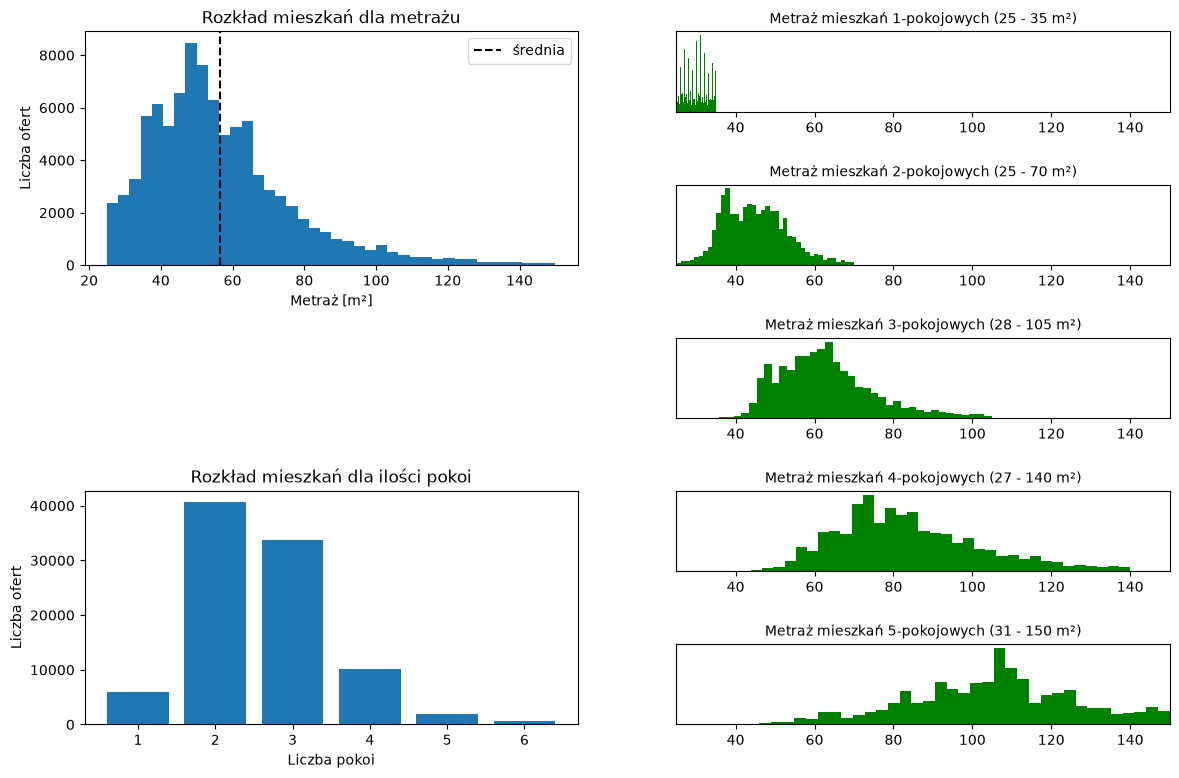

In [ ]:
from matplotlib.gridspec import GridSpec

data = df_unique.dropna(subset=["squareMeters", "rooms"])
room_numbers = [1, 2, 3, 4, 5]
xlim = (data["squareMeters"].min(), data["squareMeters"].max())

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(5, 2, figure=fig, hspace=0.9)

# left column, top: floor area of all apartments
ax = fig.add_subplot(gs[0:2, 0])
ax.hist(data["squareMeters"], bins=40)
ax.axvline(data["squareMeters"].mean(), color="black", ls="--", label="mean")
ax.set_title("Apartment area distribution")
ax.set_xlabel("Area [m²]")
ax.set_ylabel("Number of listings")
ax.legend()

# left column, bottom: number of rooms
ax = fig.add_subplot(gs[3:5, 0])
counts = data["rooms"].value_counts().sort_index()
ax.bar(counts.index, counts.values)
ax.set_title("Apartment distribution by number of rooms")
ax.set_xlabel("Number of rooms")
ax.set_ylabel("Number of listings")

# right column: floor area broken down by 1-5 rooms
for row, n in enumerate(room_numbers):
    ax = fig.add_subplot(gs[row, 1])
    area = data.loc[data["rooms"] == n, "squareMeters"]
    ax.hist(area, bins=40, color="green")
    ax.set_xlim(xlim)
    ax.set_yticks([])
    ax.set_title(f"Area of {n}-room apartments "
                 f"({area.min():.0f} - {area.max():.0f} m²)", fontsize=10)

plt.show()

Two-room apartments have the most listings. Probably the most interesting observation is that some people divided a 27 m² apartment into 4 rooms, and a 31 m² apartment into 5 rooms!

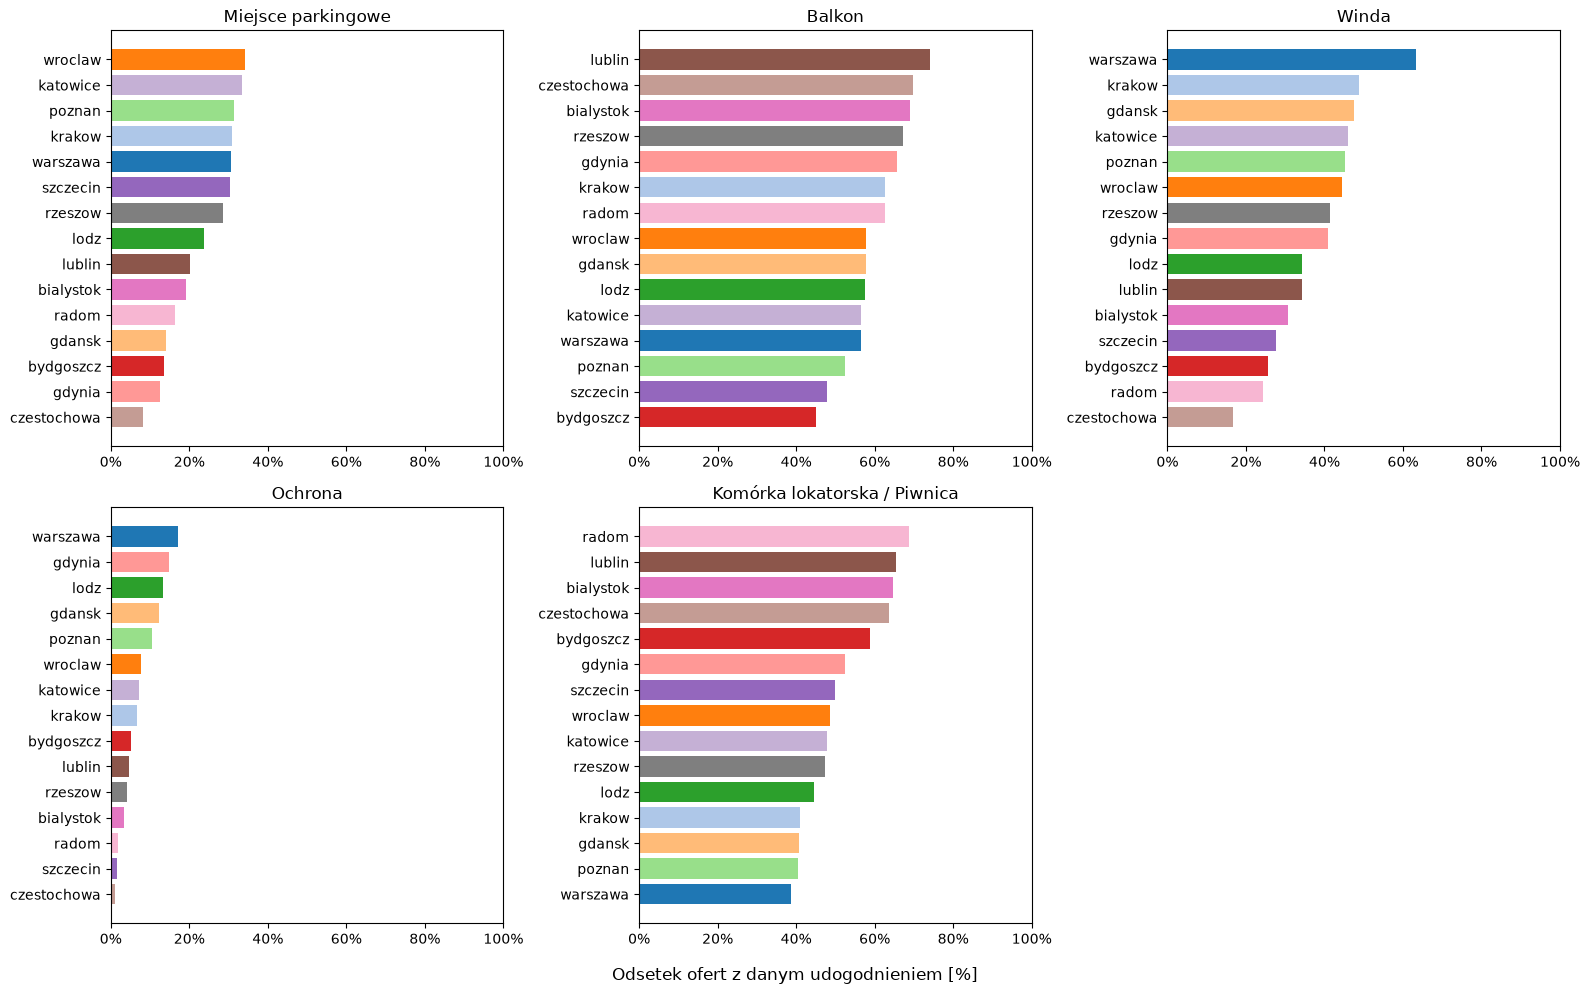

In [557]:
from matplotlib.ticker import PercentFormatter

titles = {
    "hasParkingSpace": "Parking space",
    "hasBalcony":      "Balcony",
    "hasElevator":     "Elevator",
    "hasSecurity":     "Security",
    "hasStorageRoom":  "Storage room / Basement",
}

cities = sorted(df_unique["city"].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (col, title) in zip(axes.flat, titles.items()):
    udzial = (df_unique.groupby("city")[col]
              .apply(lambda s: (s == "yes").mean() * 100)
              .sort_values())
    ax.barh(udzial.index, udzial.values,
            color=[colors[m] for m in udzial.index])
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter())

for ax in axes.flat[len(titles):]:
    ax.axis("off")

fig.supxlabel("Share of listings with a given amenity [%]")
plt.tight_layout()
plt.show()


- The availability of amenities varies a lot between categories. A balcony is the standard (50-75% of listings have one in most cities), while security is rare (below 20% everywhere, below 10% in most cities). A parking space is declared in only 10-40% of listings, which, given today's market, suggests it's more often sold separately than included in the apartment listing.
- The ranking of cities changes between panels, which reflects differences in building structure. Warsaw clearly leads in elevators (around 65% of listings) and security, matching its large share of new, high-rise buildings. Smaller cities (Radom, Bialystok, Czestochowa, Lublin), on the other hand, lead in balconies and storage rooms/basements but trail in elevators, which fits their lower, often older block-style buildings.

### Summary of the Exploratory Analysis

- The dataset contains apartment listings from more than a dozen Polish cities across several months; after removing duplicates and repeated `id`s, just over 90k records remain.
- Prices are strongly right-skewed and differ clearly between cities (the highest medians are in the largest agglomerations), as shown in the box plots. Warsaw is the most expensive, while Czestochowa and Radom are the cheapest.
- Floor area (`squareMeters`) is most strongly correlated with price, followed by the number of rooms; variables such as build year or coordinates show a weaker correlation.
- Strong correlations between the `distance` features of different points of interest suggest that POIs are usually located close to one another.
- The geographic coordinates correctly match the assigned cities (see the map), so the location data is consistent.
- Missing values occur mainly in the `type`, `floor`, `buildYear`, and `buildingMaterial` columns. These missing values will determine which columns and rows make it into the model and which don't.
- Removing duplicates and keeping the "oldest" repeated `id` shrank the dataset by more than 50%. It's hard to tell whether so many repetitions come from scraping different portals, or from consistent long-term scraping that duplicates long-standing listings across consecutive months.

## 5. Preparing the Data for Modeling

Selecting the columns for the model and checking the number of missing values in each. First and foremost, the `id` column is dropped.

In [26]:
df_unique_ml = df_unique[['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear', 'latitude', 'longitude', 'ownership', 'buildingMaterial', 'condition', 'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price']].copy()
df_unique_ml.isna().sum()

city                    0
type                19792
squareMeters            0
rooms                   0
floor               15978
floorCount           1067
buildYear           15583
latitude                0
longitude               0
ownership               0
buildingMaterial    39145
condition           69861
hasParkingSpace         0
hasBalcony              0
hasElevator          4423
hasSecurity             0
hasStorageRoom          0
price                   0
dtype: int64

Statistics for the text columns selected for the model.

In [27]:
df_unique_ml.describe(exclude = "number")

,city,type,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
count,92967,73175,92967,53822,23106,92967,92967,88544,92967,92967
unique,15,3,3,2,2,2,2,2,2,2
top,warszawa,blockOfFlats,condominium,brick,premium,no,yes,yes,no,no
freq,31982,46345,83365,40551,12696,67903,54067,45392,82374,51820


We assume that empty entries in the `condition` column simply mean a standard condition — neither premium nor low. We fill the missing values with that value.

In [28]:
df_unique_ml["condition"] = df_unique_ml["condition"].fillna("standard")
df_unique_ml.info()

<class 'pandas.DataFrame'>
Index: 92967 entries, 1 to 195564
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              92967 non-null  str    
 1   type              73175 non-null  str    
 2   squareMeters      92967 non-null  float64
 3   rooms             92967 non-null  float64
 4   floor             76989 non-null  float64
 5   floorCount        91900 non-null  float64
 6   buildYear         77384 non-null  float64
 7   latitude          92967 non-null  float64
 8   longitude         92967 non-null  float64
 9   ownership         92967 non-null  str    
 10  buildingMaterial  53822 non-null  str    
 11  condition         92967 non-null  str    
 12  hasParkingSpace   92967 non-null  str    
 13  hasBalcony        92967 non-null  str    
 14  hasElevator       88544 non-null  str    
 15  hasSecurity       92967 non-null  str    
 16  hasStorageRoom    92967 non-null  str    
 17  price   

We also drop the `buildingMaterial` column, since its missing values make up more than 30% of what remains.

In [29]:
df_unique_ml = df_unique_ml[['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear', 'latitude', 'longitude', 'ownership', 'condition', 'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price']].copy()
df_unique_ml.isna().sum()

city                   0
type               19792
squareMeters           0
rooms                  0
floor              15978
floorCount          1067
buildYear          15583
latitude               0
longitude              0
ownership              0
condition              0
hasParkingSpace        0
hasBalcony             0
hasElevator         4423
hasSecurity            0
hasStorageRoom         0
price                  0
dtype: int64

A look at the data after filling in `condition` and dropping `buildingMaterial`.

In [30]:
df_unique_ml.head(20)

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,ownership,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
1,szczecin,blockOfFlats,94.40,4.00,4.00,5.00,NaN,53.44,14.51,condominium,premium,yes,yes,no,no,yes,1150000
2,szczecin,NaN,48.29,2.00,8.00,11.00,2014.00,53.40,14.53,condominium,standard,yes,yes,yes,no,yes,625000
4,szczecin,tenement,35.92,2.00,NaN,NaN,NaN,53.42,14.54,condominium,low,yes,no,no,no,no,299000
7,szczecin,tenement,89.80,3.00,3.00,3.00,1930.00,53.43,14.53,condominium,standard,no,yes,no,no,yes,649000
11,szczecin,tenement,43.32,2.00,4.00,4.00,1930.00,53.42,14.55,condominium,standard,no,no,no,no,yes,330000
13,szczecin,blockOfFlats,68.94,3.00,3.00,4.00,1950.00,53.41,14.53,condominium,low,no,yes,no,no,yes,560000
14,szczecin,blockOfFlats,53.26,2.00,7.00,11.00,1985.00,53.46,14.49,cooperative,standard,no,yes,no,no,yes,514000
16,szczecin,tenement,58.11,3.00,1.00,3.00,1950.00,53.45,14.55,condominium,low,no,no,no,no,yes,395000
18,szczecin,blockOfFlats,70.00,4.00,2.00,2.00,2019.00,53.39,14.47,condominium,standard,no,yes,no,no,no,639000
19,szczecin,blockOfFlats,70.55,4.00,4.00,4.00,1987.00,53.38,14.67,condominium,standard,no,yes,no,no,yes,515000


Checking the remaining missing values before finally dropping incomplete rows.

In [31]:
df_unique_ml.isna().sum()

city                   0
type               19792
squareMeters           0
rooms                  0
floor              15978
floorCount          1067
buildYear          15583
latitude               0
longitude              0
ownership              0
condition              0
hasParkingSpace        0
hasBalcony             0
hasElevator         4423
hasSecurity            0
hasStorageRoom         0
price                  0
dtype: int64

---
## 6. Shallow Neural Network in Keras: Apartment Price Prediction (Regression)

---

We build a shallow neural network (a single hidden `Dense` layer) that predicts an apartment's price from its features. Price is a continuous value, so this is a regression task, and that choice shapes both the network's architecture and how it's evaluated:

- the output layer has 1 neuron with no activation (a linear output),
- the loss function is `mse` (mean squared error),
- the metric is `mae` (mean absolute error, in PLN).

We prepare the data in two steps: one-hot encoding the text columns, and standardizing the numeric features, which are on very different scales. We then split the data into training, validation, and test sets, train the network, and evaluate it on data it has never seen.

**Dropping rows with missing values**

The network can't accept `NaN` values, so from `df_unique_ml` we create `df_unique_ml_reduced`, a copy without any row that contains a missing value.

In [32]:
df_unique_ml_reduced = df_unique_ml.dropna().copy()

print(df_unique_ml.shape, "->", df_unique_ml_reduced.shape)
df_unique_ml_reduced.isna().sum()


(92967, 17) -> (51472, 17)


city               0
type               0
squareMeters       0
rooms              0
floor              0
floorCount         0
buildYear          0
latitude           0
longitude          0
ownership          0
condition          0
hasParkingSpace    0
hasBalcony         0
hasElevator        0
hasSecurity        0
hasStorageRoom     0
price              0
dtype: int64

The final size of the data frame is `51,472` rows, roughly a quarter of the full dataset. That should be enough data to work with.

**Splitting into features `X` and target `y`**

`y` is the `price` column (the value we want to predict). `X` is the remaining columns, which the network uses to predict the price.

In [33]:
X = df_unique_ml_reduced.drop(columns="price")
y = df_unique_ml_reduced["price"]

X.shape, y.shape


((51472, 16), (51472,))

**Encoding categorical variables (one-hot)**

We turn the text and boolean columns into 0/1 columns using `pd.get_dummies`. `drop_first=True` removes one redundant column from each group, and `astype("float32")` casts everything to the type Keras expects.

In [34]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype("float32")

print("Number of features after encoding:", X.shape[1])
X.head()


Liczba cech po zakodowaniu: 32


,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,city_bydgoszcz,city_czestochowa,city_gdansk,...,type_tenement,ownership_cooperative,ownership_udział,condition_premium,condition_standard,hasParkingSpace_yes,hasBalcony_yes,hasElevator_yes,hasSecurity_yes,hasStorageRoom_yes
7,89.80,3.00,3.00,3.00,1930.00,53.43,14.53,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00
11,43.32,2.00,4.00,4.00,1930.00,53.42,14.55,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
13,68.94,3.00,3.00,4.00,1950.00,53.41,14.53,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
14,53.26,2.00,7.00,11.00,1985.00,53.46,14.49,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00
16,58.11,3.00,1.00,3.00,1950.00,53.45,14.55,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


**Splitting into training and test sets**

We split the data 80/20 using `train_test_split`. `random_state=42` makes the split reproducible. We set the test set aside for the final evaluation, on data the model never saw during training.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((41177, 32), (10295, 32))

**Standardizing the features and the target**

The features are on very different scales (floor area, coordinates), so we standardize them. `StandardScaler` rescales each column to a mean of 0 and a standard deviation of 1. We fit the scaler only on the training set and merely transform the test set with it, so that no information from the test set leaks into training. We also scale the price itself, which keeps the loss from reaching huge values, and the stored `y_scaler` lets us convert the error back into PLN.

In [36]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

X_train.shape, y_train.shape


((41177, 32), (41177, 1))

**Setting aside a validation set**

We carve out 20% of the training data as a validation set. After every epoch we check how the network performs on data outside the training set. The data has already been split and shuffled, so it's enough to cut off the first slice.

In [37]:
val_count = int(len(X_train) * 0.2)

X_val = X_train[:val_count]
y_val = y_train[:val_count]
X_train = X_train[val_count:]
y_train = y_train[val_count:]

X_train.shape, X_val.shape, X_test.shape


((32942, 32), (8235, 32), (10295, 32))

**Building the shallow network (regression)**

`set_random_seed(42)` fixes the seed of the random generators, so that weight initialization and data shuffling are reproducible and every run gives the same result.

The sequential model:

- `Input(shape=(number_of_features,))` is the input layer,
- `Dense(128, relu)` is the single hidden layer,
- `Dense(1)` is the output layer with one neuron and no activation (the predicted price).

In [508]:
from keras.utils import set_random_seed

# fixed seed: reproducible weight initialization and batch shuffling
set_random_seed(42)

network = models.Sequential()
network.add(layers.Input(shape=(X_train.shape[1],)))
network.add(layers.Dense(128, activation='relu'))
network.add(layers.Dense(1))

**Network Architecture**

In [509]:
network.summary()


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

**Training parameters**

- `optimizer=Adam(learning_rate=0.0001)`. Adam adapts the learning rate separately for each weight (like RMSprop) and additionally averages the gradients themselves (momentum), which makes training stable. A learning rate of 0.0001 is ten times smaller than the default; training takes longer as a result, but it proceeds more smoothly and the curves are easier to read.
- `loss="mse"` (mean squared error, the typical loss for regression),
- `metrics=["mae"]` (mean absolute error, easy to interpret in PLN).

In [510]:
from keras.optimizers import Adam

network.compile(optimizer=Adam(learning_rate=0.0001),
                loss='mse',
                metrics=['mae'])


Checking the range of the standardized target. After standardization, typical values fall roughly between -2 and 2, and the noticeably larger maximum shows just how far the right tail of the price distribution stretches away from the rest (almost 6).

In [558]:
y_train.min(), y_train.max()

(np.float64(-1.6111971022107974), np.float64(5.981094525139427))

**Training the network**

`history` records the loss and `mae` after every epoch (for both training and validation). We set `epochs=500` with plenty of headroom, and let `EarlyStopping` decide when training actually ends: it stops training once the validation loss hasn't improved for 15 consecutive epochs (`patience=15`), and restores the weights from the best epoch (`restore_best_weights=True`). This way there's no need to guess the right number of epochs, and the model doesn't get the chance to overfit.

In [512]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          
    patience=15,                 
    restore_best_weights=True    
)

history = network.fit(X_train, y_train,
                      epochs=500,
                      batch_size=64,
                      validation_data=(X_val, y_val),
                      callbacks=[early_stop])


Epoch 1/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - loss: 0.5335 - mae: 0.4982 - val_loss: 0.3366 - val_mae: 0.4041
Epoch 2/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.2955 - mae: 0.3762 - val_loss: 0.2738 - val_mae: 0.3640
Epoch 3/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.2541 - mae: 0.3471 - val_loss: 0.2473 - val_mae: 0.3434
Epoch 4/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.2350 - mae: 0.3323 - val_loss: 0.2343 - val_mae: 0.3326
Epoch 5/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.2248 - mae: 0.3240 - val_loss: 0.2269 - val_mae: 0.3261
Epoch 6/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.2184 - mae: 0.3187 - val_loss: 0.2219 - val_mae: 0.3217
Epoch 7/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.2139 - mae: 0.3148 - val_loss: 0.2183 - val_mae: 0.3183
Epoch 8/500
515/515 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.2105 - mae: 0.3117 - val_loss: 0.2156 - val_mae: 0.3156
Epoch 9/500
515/515 ━━━━━━━━━━━━

In [524]:
print("Training stopped after epoch:", len(history.history['val_loss']))
print("Best epoch:", np.argmin(history.history['val_loss']) + 1)

Trening zatrzymany po epoce: 209
Najlepsza epoka: 194


**Evaluating on the test set**

We evaluate the network on the held-out test set. `evaluate` returns the loss (`mse`) and `mae` in standardized units. Multiplying `mae` by the price's standard deviation stored in `y_scaler` gives us the error in PLN.

In [513]:
test_mse, test_mae = network.evaluate(X_test, y_test)

mae_pln = test_mae * y_scaler.scale_[0]
print('test MAE (standardized):', test_mae)
print('test MAE (PLN):', mae_pln)


322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step - loss: 0.1869 - mae: 0.2930
test MAE (wystandaryzowane): 0.29303404688835144
test MAE (zł): 119602.08446504868


**Training curve: loss**

Plot of the `mse` loss for the training and validation sets. A widening gap between the two curves would indicate overfitting.

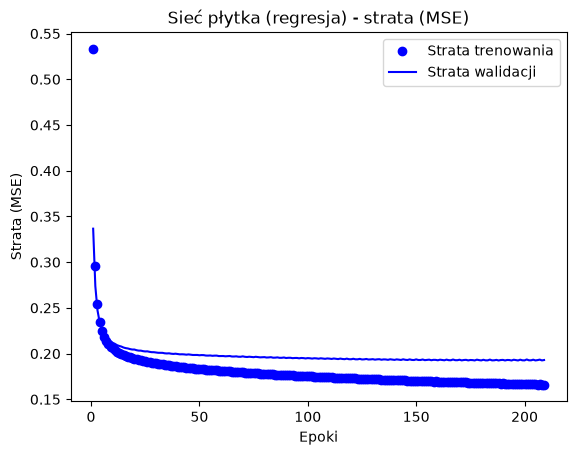

In [514]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Shallow network (regression) - loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


**Training curve: MAE**

Plot of the mean absolute error (in standardized units) for training and validation.

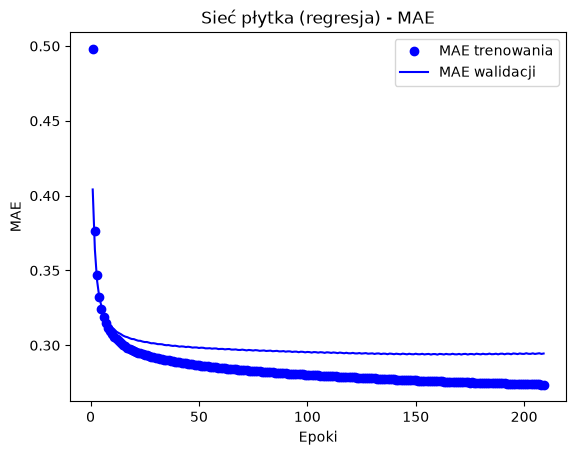

In [515]:
mae = history.history['mae']
val_mae = history.history['val_mae']

plt.plot(epochs, mae, 'bo', label='Training MAE')
plt.plot(epochs, val_mae, 'b', label='Validation MAE')
plt.title('Shallow network (regression) - MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


**Predictions on the test set**

The training curves show how training thresholdressed, but not how the model is wrong on specific apartments. So we convert back to PLN (`inverse_transform`) and plot the predicted price against the actual price for the whole test set. A perfect model would place every point on the red diagonal line.

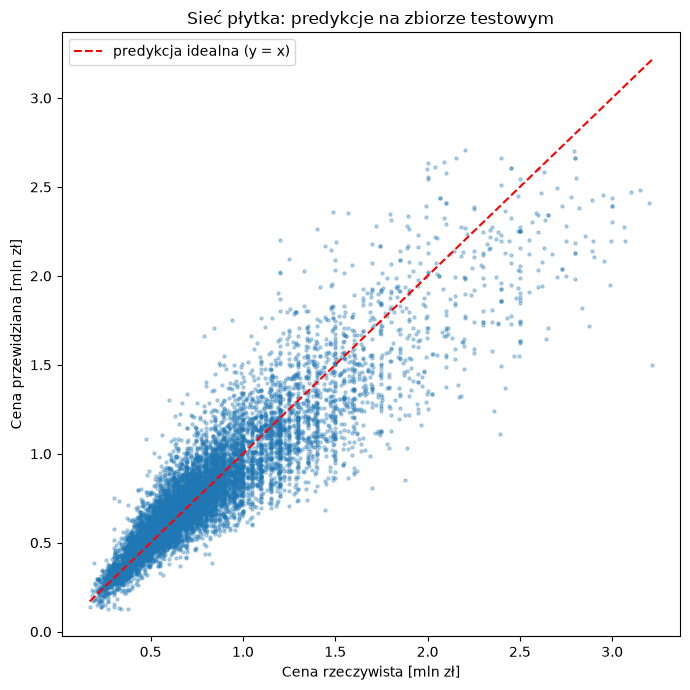

In [516]:
y_true_zl = y_scaler.inverse_transform(y_test).ravel()
y_pred_zl = y_scaler.inverse_transform(network.predict(X_test, verbose=0)).ravel()

plt.figure(figsize=(7, 7))
plt.scatter(y_true_zl / 1e6, y_pred_zl / 1e6, s=5, alpha=0.3)
lim = [y_true_zl.min() / 1e6, y_true_zl.max() / 1e6]
plt.plot(lim, lim, 'r--', label='ideal prediction (y = x)')
plt.xlabel("Actual price [mln PLN]")
plt.ylabel("Predicted price [mln PLN]")
plt.title("Shallow network: predictions on the test set")
plt.legend()
plt.tight_layout()
plt.show()

**Prediction error plot**

The same picture from another angle: for each apartment we plot the difference between the predicted and actual price. A symmetric cloud of constant width around zero would mean an error independent of price. A widening funnel, with points drifting downward for expensive apartments, means the error grows with price, and that expensive apartments (above 1 million PLN) are underestimated.

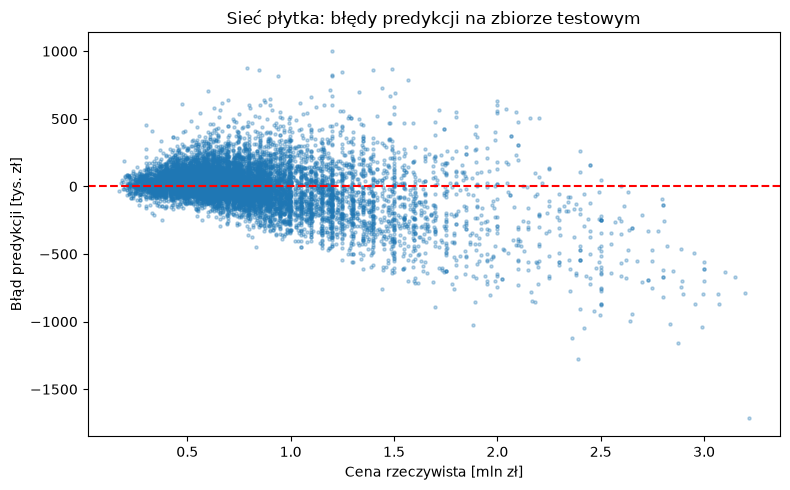

In [517]:
errors = y_pred_zl - y_true_zl

plt.figure(figsize=(8, 5))
plt.scatter(y_true_zl / 1e6, errors / 1e3, s=5, alpha=0.3)
plt.axhline(0, color='r', ls='--')
plt.xlabel("Actual price [mln PLN]")
plt.ylabel("Prediction error [thousand PLN]")
plt.title("Shallow network: prediction errors on the test set")
plt.tight_layout()
plt.show()

**Error by price segment**

To confirm the observation from the plots, we compute MAE separately for apartments up to 1 million PLN and for more expensive ones.

In [518]:
threshold = 1_000_000
mask = y_true_zl <= threshold

print(f"MAE up to 1 million PLN:      {np.abs(errors[mask]).mean():>10,.0f} PLN  ({mask.mean():.0%} of the test set)")
print(f"MAE above 1 million PLN: {np.abs(errors[~mask]).mean():>10,.0f} PLN  ({(~mask).mean():.0%} of the test set)")

MAE do 1 mln zł:          88,680 zł  (79% zbioru testowego)
MAE powyżej 1 mln zł:    237,995 zł  (21% zbioru testowego)


**Training Results and Conclusions**

Numerical results:

- Training started with a limit of 500 epochs, but `EarlyStopping` stopped it after 209 epochs, restoring the weights from epoch 194, where the validation loss was lowest. This confirms that further training was no longer bringing any improvement.
- On the test set, the network reaches `mse` = 0.187 in standardized units. A model that always guessed the average price would have a loss around 1.0 on this rescaled target, so the network explains about 81% of the price variance (R² = 0.812).
- The mean absolute error is about 120 thousand PLN, roughly 17% of the dataset's median price (715 thousand PLN). That error is clearly too large to price a specific apartment; the model captures the general price level, but can miss an individual listing by well over ten percent.

How training thresholdressed:

- At a learning rate of 0.0001, both curves decrease smoothly: the training loss goes from 0.53 after the first epoch down to about 0.17 at the end, and the validation loss flattens out around 0.19. The gap between the curves stays small and stable, so overfitting is minimal, and the test result (0.187) is nearly identical to the validation result.

Conclusions from the prediction plots:

- The plot of predicted versus actual price shows a clear cloud along the diagonal for cheaper apartments, and growing scatter above roughly 1 million PLN, where points drift further below the diagonal. Expensive apartments are systematically underestimated: the model pulls their prices toward the average.
- This is confirmed by the segment breakdown: for apartments up to 1 million PLN (79% of the test set), MAE is about 89 thousand PLN, while for more expensive ones (21% of the set) it's about 238 thousand PLN — nearly three times as much. The overall average of 120 thousand PLN is therefore misleading: the model performs clearly better in the popular segment, and the average is inflated by expensive apartments, where the `mse` loss and the long right tail of the price distribution take their toll.
- About 19% of the price variance remains unexplained, and given the features used, that's understandable: the data doesn't include information that, in practice, strongly differentiates price, especially in the premium segment (exact location, finishing standard, view). No amount of extra network size or training time can make up for that gap. On top of that, part of the problem may be speculation and artificial price inflation, driven simply by demand for apartments with "premium" features or that signal higher social status, rather than apartments that are actually "better" or more attractive as real estate.

---
## 7. Comparison with a Decision Tree

---

We compare the shallow network only against a decision tree (`DecisionTreeRegressor`), since Naive Bayes isn't suited to predicting continuous values.

**Decision tree**

We train the tree on the same data as the network. `max_depth=8` limits the tree's depth. Without this limit, the tree fits individual training observations (overfitting). This cell is self-contained: it defines its own scoring function and immediately compares the tree against the shallow network on the same test set.

In [519]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def model_results(model_name, y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mse = mean_squared_error(y_true, y_pred)
    mae_zl = mean_absolute_error(y_true, y_pred) * y_scaler.scale_[0]
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name:18s} | MSE: {mse:.3f} | MAE: {mae_zl:>12,.0f} PLN | R2: {r2:.3f}")

# decision tree trained on the same data as the network
tree = DecisionTreeRegressor(max_depth=8, random_state=42)
tree.fit(X_train, y_train.ravel())

# compare both models on the same test set
model_results("Shallow network", y_test, network.predict(X_test, verbose=0))
model_results("Decision tree", y_test, tree.predict(X_test))

Sieć płytka        | MSE: 0.187 | MAE:      119,602 zł | R2: 0.812
Drzewo decyzyjne   | MSE: 0.202 | MAE:      123,741 zł | R2: 0.797


**Feature importance according to the tree**

Trees give an interpretable ranking of features, which nicely rounds off the earlier correlation analysis. We expect floor area (`squareMeters`) to dominate.

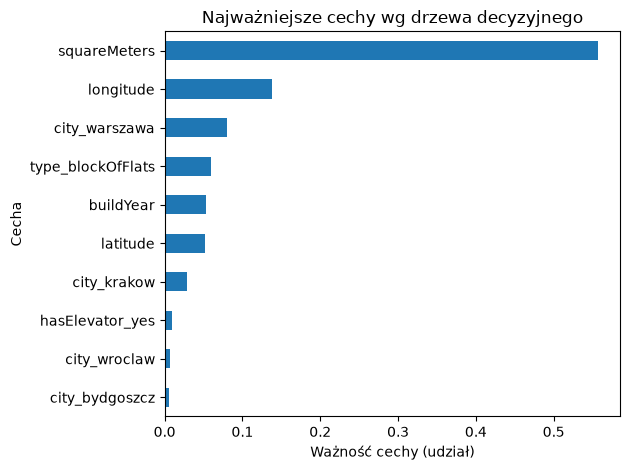

In [520]:
importances = pd.Series(tree.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(10).plot.barh()
plt.title("Most important features by decision tree")
plt.xlabel("Feature importance (share)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Comparing the network's and the tree's predictions**

The same test-set predictions for both models on a single plot. This shows whether the models make similar mistakes, and whether either one handles expensive apartments better.

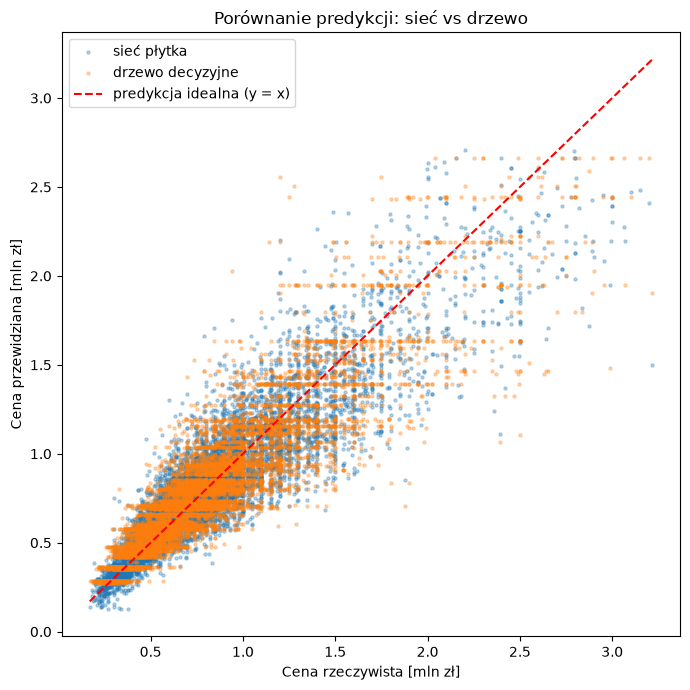

In [521]:
y_pred_tree_zl = y_scaler.inverse_transform(tree.predict(X_test).reshape(-1, 1)).ravel()

plt.figure(figsize=(7, 7))
plt.scatter(y_true_zl / 1e6, y_pred_zl / 1e6, s=5, alpha=0.3, label="shallow network")
plt.scatter(y_true_zl / 1e6, y_pred_tree_zl / 1e6, s=5, alpha=0.3, label="decision tree")
lim = [y_true_zl.min() / 1e6, y_true_zl.max() / 1e6]
plt.plot(lim, lim, 'r--', label='ideal prediction (y = x)')
plt.xlabel("Actual price [mln PLN]")
plt.ylabel("Predicted price [mln PLN]")
plt.title("Prediction comparison: network vs tree")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusions from the Comparison**

- The shallow network performs slightly better than the decision tree: R² of 0.812 versus 0.797, and MAE of about 120 thousand PLN versus about 124 thousand PLN. A difference of about 4 thousand PLN in average error is small in practice, given the price range of the apartments.
- The comparison plot shows both models make similar mistakes: the point clouds largely overlap, and above 1 million PLN both systematically underestimate. The tree's predictions form horizontal bands, because a depth-8 tree can only output a finite number of values (the average price in each leaf), while the network produces continuous predictions.
- Two completely different methods land at nearly the same level, which suggests the bottleneck isn't model capacity but the information available in the features. If the network were too small, the tree would clearly outperform it, and that isn't what happens.
- The tree trains faster, needs neither standardization nor one-hot encoding, and gives an interpretable feature-importance ranking that directly shows the dominance of floor area. The network wins here only marginally on quality, at the cost of longer training and more data-preparation steps.

---
## 8. Final Conclusions

- The problem of predicting apartment prices from tabular features can be modeled with a shallow neural network, but the results reveal clear limits to this approach. The network (one hidden layer, 128 neurons, learning rate 0.0001, training stopped by `EarlyStopping` after 209 epochs with the weights from epoch 194) explains about 81% of the price variance (R² = 0.812), with a mean error of about 120 thousand PLN, roughly 17% of the median price.
- That error is very uneven across segments: for apartments up to 1 million PLN (79% of the test set) it's about 89 thousand PLN, and for more expensive ones about 238 thousand PLN. So the model is reasonably useful in the popular segment (rough price orientation, comparing listings, spotting clear outliers), but in the premium segment it systematically underestimates and shouldn't be relied on.
- The decision tree achieves a similar result (R² = 0.797) with much simpler data preparation, and makes mistakes in a similar way to the network.
- During the work, a smaller network (64 neurons) and a larger learning rate were also tested, and the test result barely changed. All of this suggests that the ceiling on quality is set by the data, not by the architecture or the hyperparameters.
- The natural next step is to work on the data, not on the shallow network.

---

*This project was built as a learning exercise on shallow neural networks and regression, based on the "Apartment Prices in Poland" dataset from Kaggle.*